# Generation and post-analysis in aids dataset 

#### Associated publication
Reference: https://www.nejm.org/doi/full/10.1056/NEJM199709113371101

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tableone import TableOne
import torch
import os

import sys
from pathlib import Path
module_path = Path.cwd().parent / 'utils'
sys.path.append(str(module_path))
import data_processing, visualization
from simulations import *
module_path = Path.cwd().parent / 'execute'
sys.path.append(str(module_path))

from synthcity.metrics.plots import plot_tsne
from synthcity.metrics.eval import Metrics
from synthcity.metrics.scores import ScoreEvaluator
from synthcity.plugins.core.dataloader import SurvivalAnalysisDataLoader
from synthcity.utils.reproducibility import clear_cache, enable_reproducible_results

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[KeOps] Warning : No C++ compiler found. Define CXX environment variable or install g++.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.
[KeOps] Warning : No C++ compiler found. You need to either define the CXX environment variable pointing to a valid compiler, or ensure that 'g++' is installed and in your PATH.
[KeOps] Warning : No C++ compiler available to check for OpenMP support.
[KeOps] Warning : OpenMP support is not available. Disabling OpenMP.


## 1. Original data loading, analysis and visualization

### 1.1. Experiment setting - links to data

In [2]:
n_samples = 600
n_features_bytype = 6
n_active_features = 3 
treatment_effect = 0.4
p_treated = 0.5
shape_T = 2.
shape_C = 2.
scale_C = 2.5
scale_C_indep = 3.9
feature_types_list = ["real", "cat"]
independent = True
data_types_create = True

In [3]:
seed = 1
dataset_name = "Simulations"
current_path = os.getcwd()  # Get current working directory
parent_path = os.path.dirname(current_path)
data_file_control= parent_path + "/dataset/" + dataset_name + "/data_control.csv"
feat_types_file_control = parent_path + "/dataset/" + dataset_name + "/data_types_control.csv"
data_file_treated= parent_path + "/dataset/" + dataset_name + "/data_treated.csv"
feat_types_file_treated= parent_path + "/dataset/" + dataset_name + "/data_types_treated.csv"

# If the dataset has no missing data, leave the "miss_file" variable empty
miss_file = parent_path + "/dataset/" + dataset_name + "/Missing.csv"
true_miss_file = None
control, treated, types = simulation(treatment_effect, n_samples, independent, feature_types_list,
                                        n_features_bytype, n_active_features, p_treated, shape_T, shape_C,
                                        scale_C, scale_C_indep, data_types_create, seed=seed)
print("Censoring level of control ", control.censor.sum() / control.censor.shape[0])
print("Censoring level of treated ", treated.censor.sum() / treated.censor.shape[0])


control = control.drop(columns='treatment')
treated = treated.drop(columns='treatment')

data_file_control = parent_path + "/dataset/" + dataset_name + "/data_control.csv"
data_file_treated = parent_path + "/dataset/" + dataset_name + "/data_treated.csv"
feat_types_file_control = parent_path + "/dataset/" + dataset_name + "/data_types_control.csv"
feat_types_file_treated= parent_path + "/dataset/" + dataset_name + "/data_types_treated.csv"

control.to_csv(data_file_control, index=False , header=False)
treated.to_csv(data_file_treated, index=False , header=False)
types.to_csv(feat_types_file_control)
types.to_csv(feat_types_file_treated)


# Load and transform control data
df_init_control_encoded, feat_types_dict, miss_mask_control, true_miss_mask_control, _, dict_cat_map_control = data_processing.read_data(data_file_control, feat_types_file_control,
                                                                                                                                         miss_file, true_miss_file,
                                                                                                                                         return_cat_mapping=True)
data_init_control_encoded = torch.from_numpy(df_init_control_encoded.values)
data_init_control = data_processing.discrete_variables_transformation(data_init_control_encoded, feat_types_dict)

# Load and transform treated data
df_init_treated_encoded, _, _, _, _, dict_cat_map_treated = data_processing.read_data(data_file_treated, feat_types_file_treated, miss_file, true_miss_file,
                                                                                      return_cat_mapping=True)
data_init_treated_encoded = torch.from_numpy(df_init_treated_encoded.values)
data_init_treated = data_processing.discrete_variables_transformation(data_init_treated_encoded, feat_types_dict)

# Format data in dataframe
control_fnames = types['name'][:-1].tolist()
control_fnames.append("time")#.append("censor")
control_fnames.append("censor")

Censoring level of control  0.8403908794788274
Censoring level of treated  0.8020477815699659


### 1.2. Loading, feature analysis, and visualization of original data: control vs treated group

In [4]:
# Format data in dataframe
df_init_treated = pd.DataFrame(data_init_treated.numpy(), columns=control_fnames)
df_init_control = pd.DataFrame(data_init_control.numpy(), columns=control_fnames)

# Update the data
df_init_treated["treatment"] = 1
df_init_control["treatment"] = 0
df_init = pd.concat([df_init_control, df_init_treated], ignore_index=True)

In [5]:
continuous_variables_control = [row['name'] for row in feat_types_dict if row['type'] in ['pos', 'real']]
categorical_variables_control = [row['name'] for row in feat_types_dict if row['type'] in ['cat']]

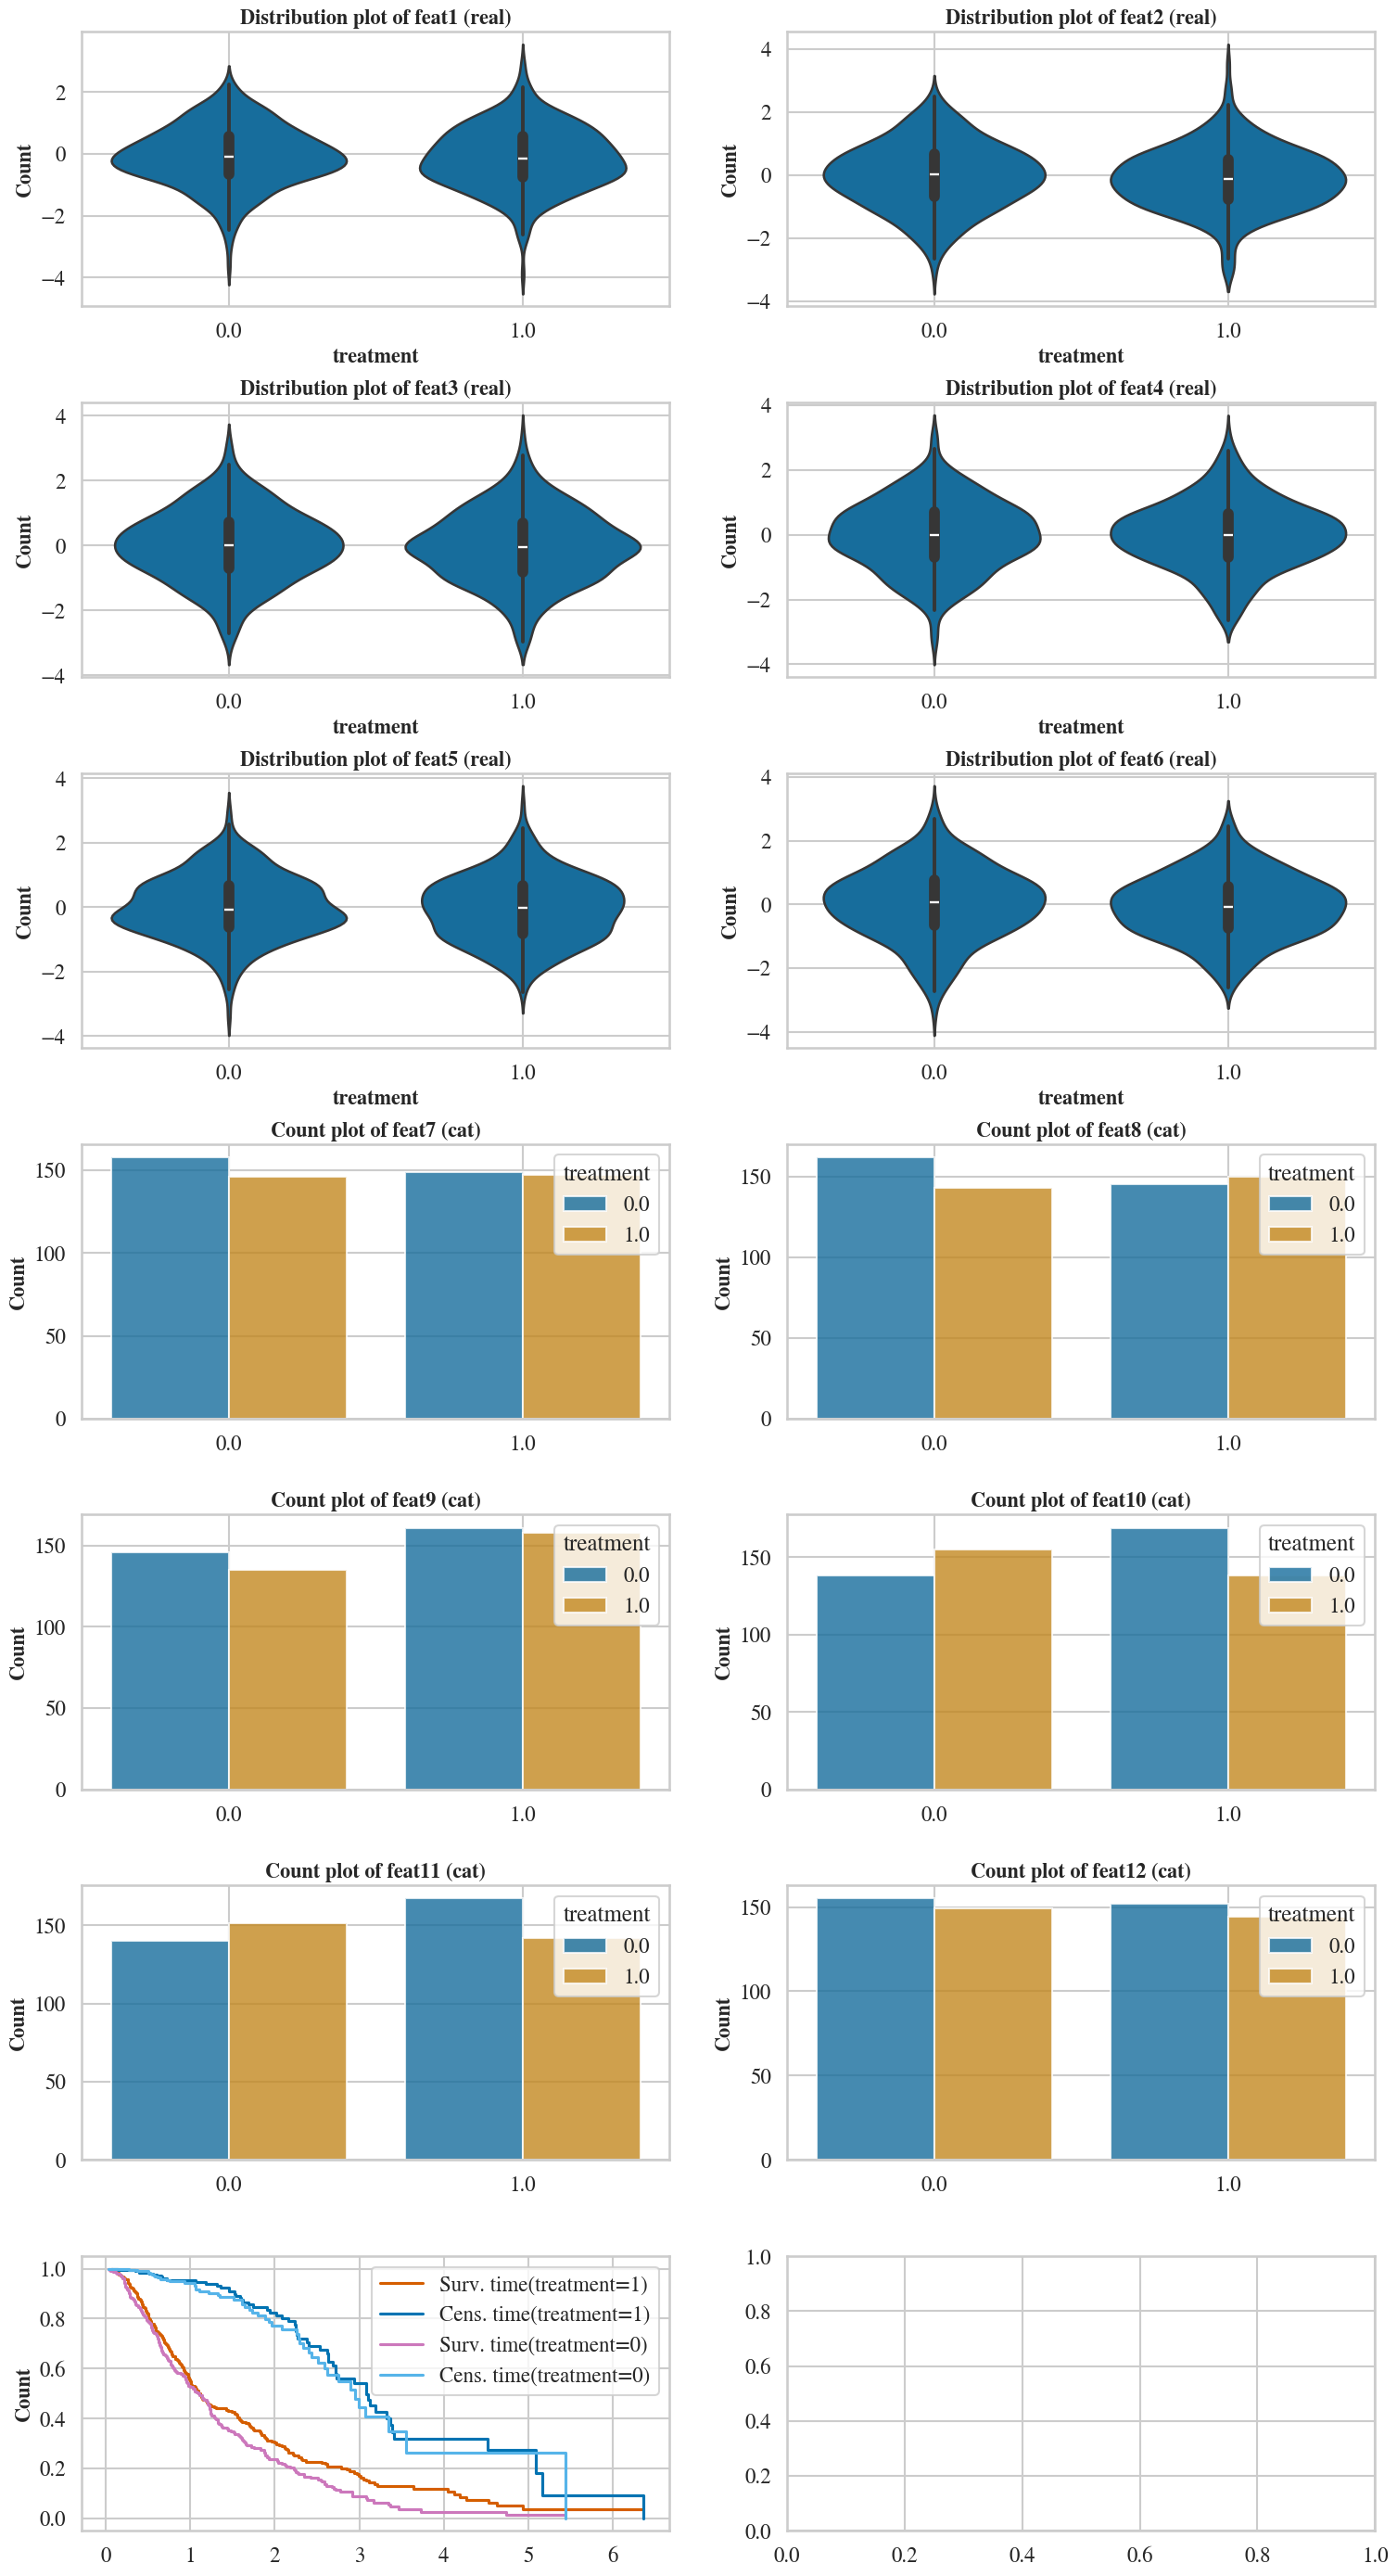

In [6]:
# TODO: Refactor
feat_types_dict_all = feat_types_dict.copy()
feat_types_dict_all.append({'name': 'treatment', 'type': 'cat', 'dim': '1', 'nclass': '2'})
visualization.plot_data(df_init.to_numpy(), feat_types_dict_all, feat_comparison_name='treatment')

In [7]:
continuous = ['time', 'feat1', 'feat2', 'feat3', 'feat4', 'feat5', 'feat6']
categorical = ['censor', 'feat7', 'feat8', 'feat9', 'feat10', 'feat11', 'feat12', 'treatment']
nonnormal = ['time']

table1 = TableOne(df_init, categorical=categorical, continuous=continuous, 
                  groupby='treatment', nonnormal=nonnormal, pval=True)
print(table1)

                         Grouped by treatment                                                     
                                      Missing        Overall              0              1 P-Value
n                                                        600            307            293        
feat1, mean (SD)                            0     -0.1 (1.0)     -0.1 (1.0)     -0.1 (1.0)   0.545
feat2, mean (SD)                            0     -0.1 (1.0)     -0.0 (1.0)     -0.1 (1.0)   0.296
feat3, mean (SD)                            0     -0.0 (1.1)     -0.0 (1.1)     -0.0 (1.1)   0.740
feat4, mean (SD)                            0     -0.0 (1.1)     -0.0 (1.1)     -0.0 (1.0)   0.799
feat5, mean (SD)                            0     -0.0 (1.0)      0.0 (1.0)     -0.1 (1.0)   0.442
feat6, mean (SD)                            0     -0.0 (1.1)      0.0 (1.1)     -0.1 (1.0)   0.378
feat7, n (%)         0.0                          304 (50.7)     158 (51.5)     146 (49.8)   0.750
          

## 2. Training and generation from the generative model

Possible generative models: HI-VAE (our), survival_gan, survival_ctgan, survival_nflow, survae (synthcity)

In [8]:
import surv_hivae, surv_vae, surv_gan
import json
# treatment_effect_best_param = 0.
# metric_optuna = "survival_km_distance"
# # Parameters of the optuna study
# multiplier_trial = 10 # multiplier for the number of trials
# n_splits = 5 # number of splits for cross-validation
# n_generated_dataset = 50 # number of generated datasets per fold to compute the metric
# name_config = "simu_N{}_nfeat{}_t{}".format(n_samples, n_features_bytype, int(treatment_effect_best_param))

# generators_sel = ["HI-VAE_weibull", "HI-VAE_piecewise", "Surv-GAN", "Surv-VAE"]
# generators_dict = {"HI-VAE_weibull" : surv_hivae,
#                 "HI-VAE_piecewise" : surv_hivae}


# # BEST PARAMETERS
# best_params_dict = {}
# for generator_name in generators_sel:
#     n_trials = 150
#     best_params_file = parent_path + "/dataset/" + dataset_name + "/optuna_results/best_params_{}_ntrials{}_{}_{}.json".format(name_config, n_trials, metric_optuna, generator_name)
#     with open(best_params_file, "r") as f:
#         best_params_dict[generator_name] = json.load(f)

# the datasets used for training is data_init_control
n_generated_dataset = 100

In [9]:
feat_types_dict_ext = feat_types_dict.copy()
for i in range(len(feat_types_dict)):
    if feat_types_dict_ext[i]['name'] == "survcens":
        feat_types_dict_ext[i]["type"] = 'surv_piecewise'
data_gen_control = surv_hivae.run(df_init_control_encoded,
                                  miss_mask_control, 
                                  true_miss_mask_control,
                                  feat_types_dict_ext,
                                  n_generated_dataset,
                                  n_layers_surv_piecewise=1,
                                  n_intervals=10,
                                  seed=1)

Epoch: [ 0]  time: 0.1596, ELBO_train: -15.51069927, KL_z: 1.81047173, KL_s: 0.07416658, reconstruction loss: -13.62606096
Epoch: [100]  time: 7.7996, ELBO_train: -11.98293336, KL_z: 1.29135712, KL_s: 0.08988308, reconstruction loss: -10.60169316
Epoch: [200]  time: 17.2958, ELBO_train: -11.94459756, KL_z: 1.64928142, KL_s: 0.03490486, reconstruction loss: -10.26041128
Epoch: [300]  time: 26.1799, ELBO_train: -11.67323176, KL_z: 1.94133246, KL_s: 0.01863085, reconstruction loss: -9.71326845
Epoch: [400]  time: 34.9158, ELBO_train: -11.37603442, KL_z: 2.23360999, KL_s: 0.01615273, reconstruction loss: -9.12627169
Epoch: [500]  time: 44.1791, ELBO_train: -11.36513869, KL_z: 2.43441463, KL_s: 0.01156464, reconstruction loss: -8.91915943
Epoch: [600]  time: 52.9260, ELBO_train: -11.27353382, KL_z: 2.58927584, KL_s: 0.01125571, reconstruction loss: -8.67300228
Epoch: [700]  time: 61.4771, ELBO_train: -11.08761056, KL_z: 2.77762238, KL_s: 0.00946435, reconstruction loss: -8.30052383
Epoch: [

## 3. Analyze the generated data

### 3.1. Statistical analysis: one generated control group vs. initial control data

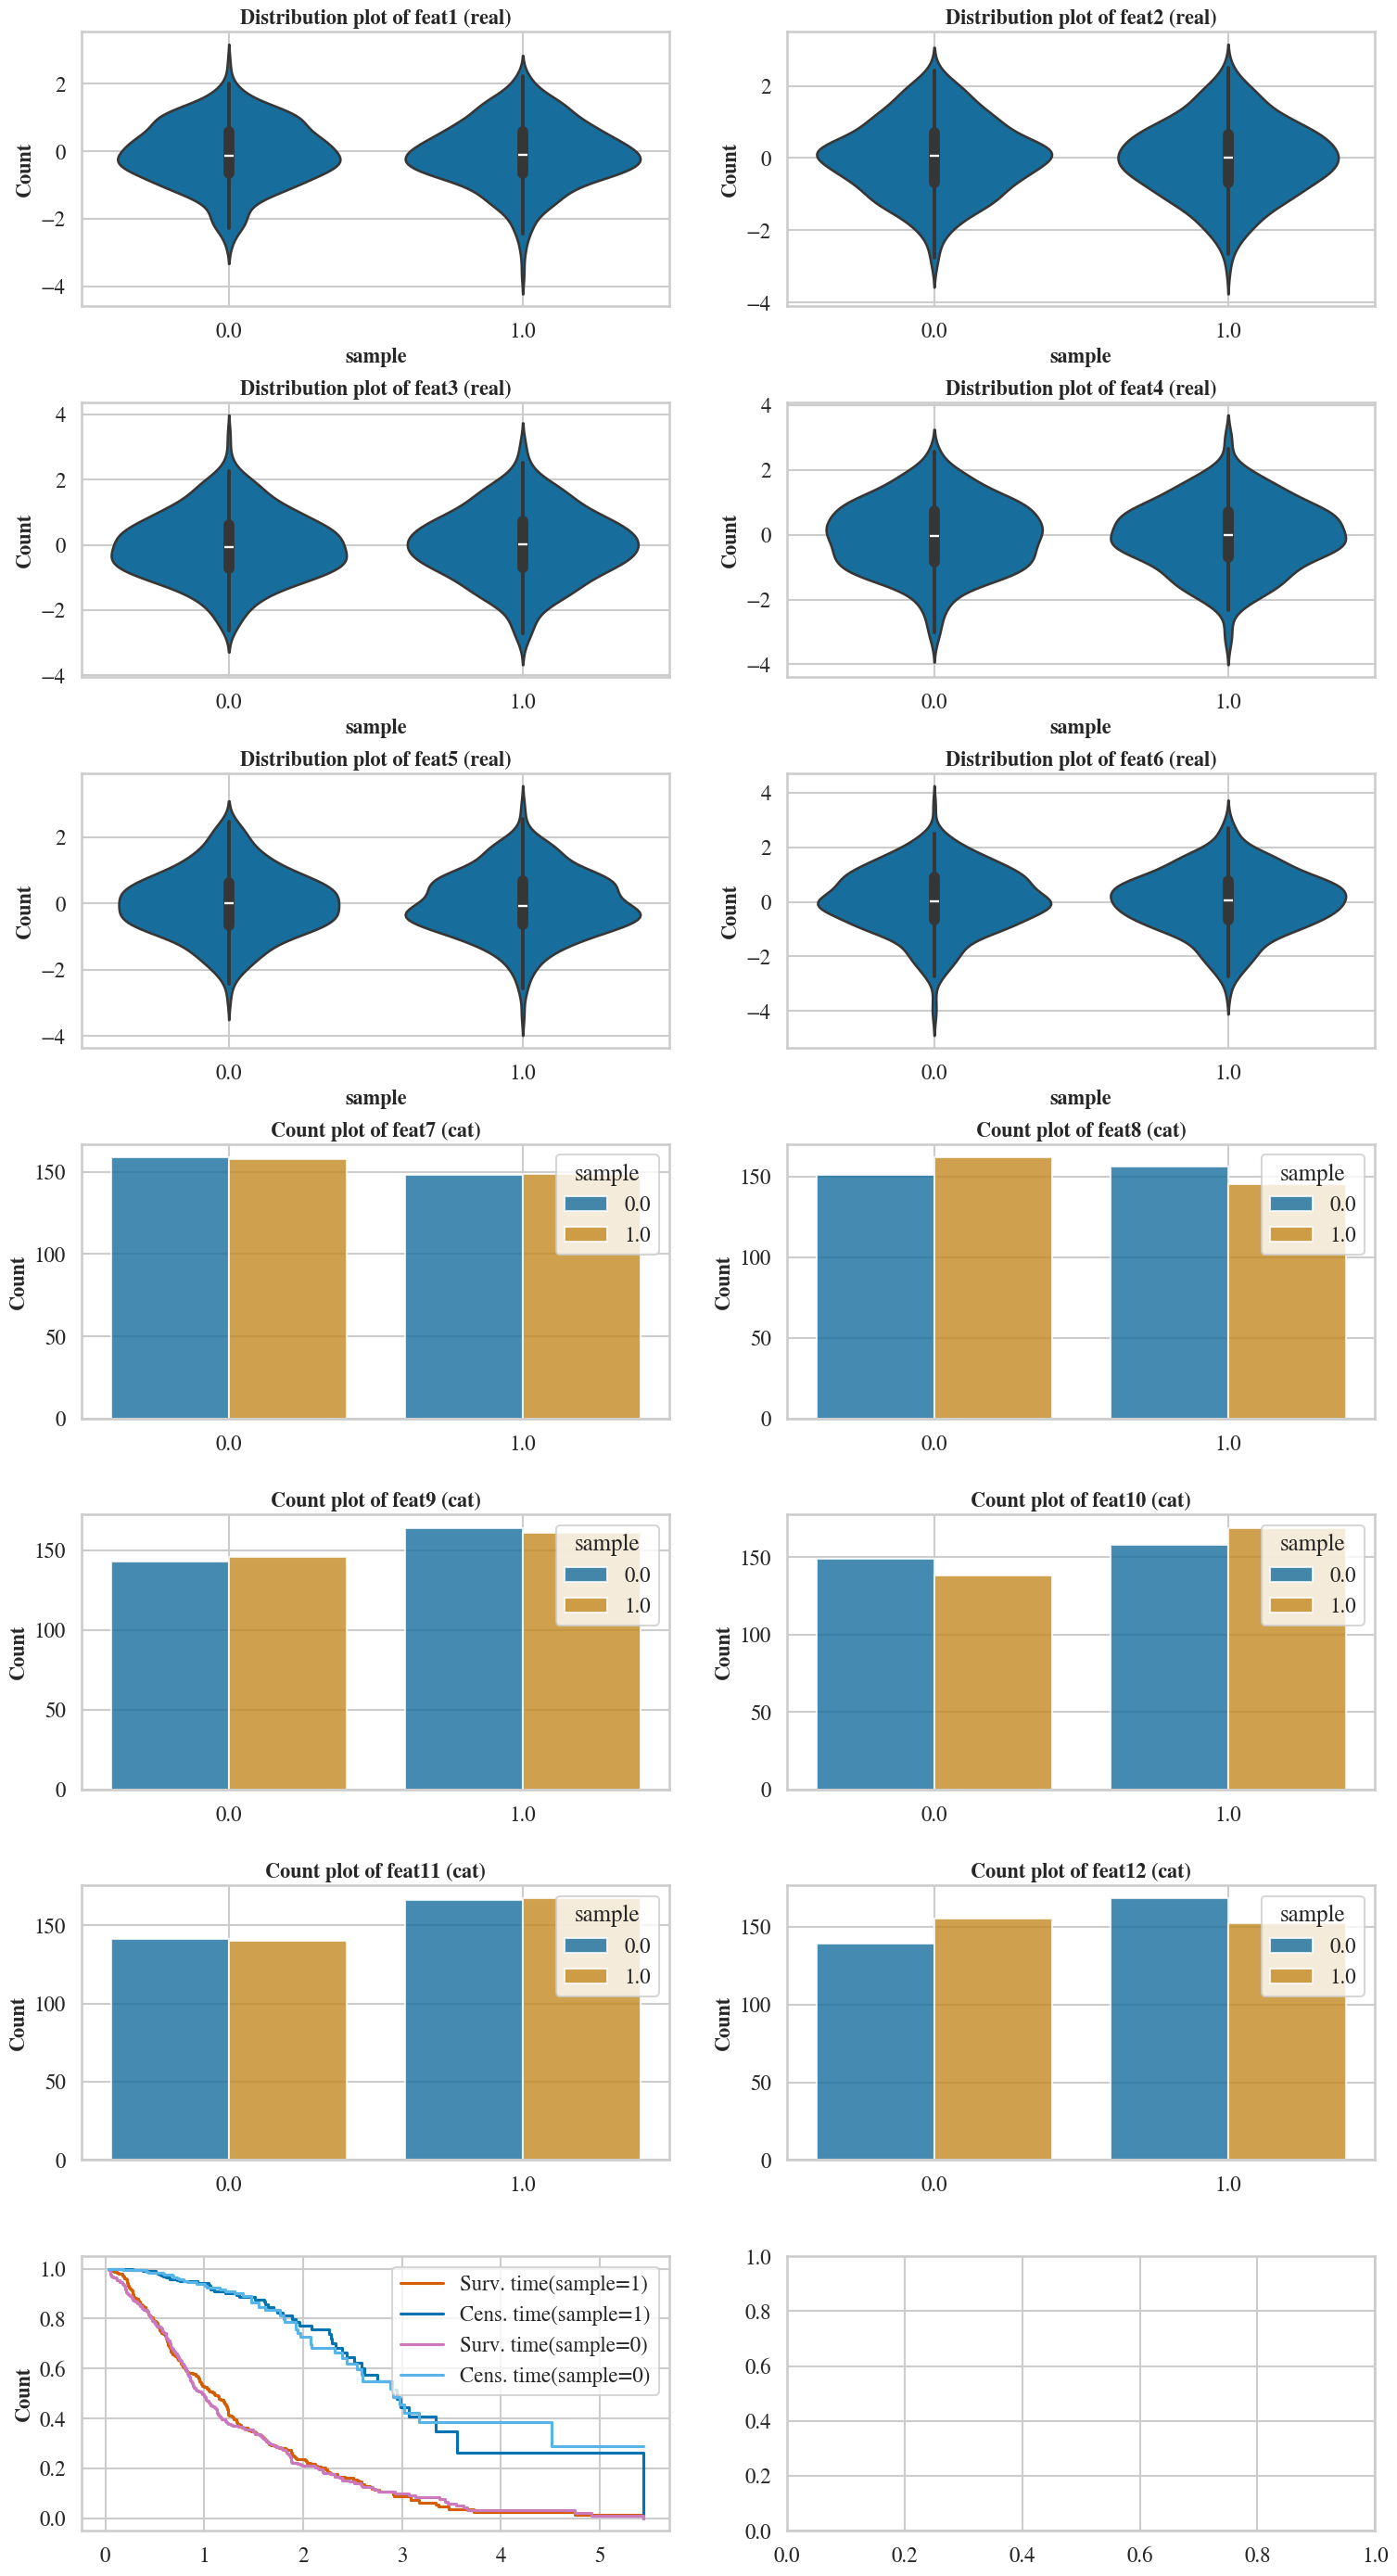

In [10]:
df_init_control_ext = pd.DataFrame(data_init_control.numpy(), columns=control_fnames)
df_init_control_ext['sample'] = 1

sel_idx = 12
df_gen_control_ext_sel = pd.DataFrame(data_gen_control[sel_idx].numpy(), columns=control_fnames)
df_gen_control_ext_sel['sample'] = 0

feat_types_dict_ext = feat_types_dict.copy()
feat_types_dict_ext.append({'name': 'sample', 'type': 'cat', 'dim': '1', 'nclass': '2'})
df_control_sel = pd.concat([df_init_control_ext, df_gen_control_ext_sel], ignore_index=True)
visualization.plot_data(df_control_sel.to_numpy(), feat_types_dict_ext, feat_comparison_name = 'sample')

## 4. Log-rank test

In [11]:
from metrics import log_rank, cox_estimation

data_syn = []
list_df_gen_control = []
for i in range(n_generated_dataset):
    df_gen_control = pd.DataFrame(data_gen_control[i].numpy(), columns=control_fnames)
    df_gen_control['treatment'] = 0
    list_df_gen_control.append(df_gen_control)
    data_syn.append(pd.concat([df_init_treated, df_gen_control], ignore_index=True))

LR_init, LR_syn = log_rank(df_init, data_syn)
coef_init, coef_syn, cox_p_value_init, cox_p_value_syn = cox_estimation(df_init, data_syn)

## 5. Scores

In [12]:
_round_cols = continuous_variables_control + ['time']
_round_step = data_processing.infer_rounding_steps(df_init_control, _round_cols, coverage=0.99)
_round_floor = {c: df_init_control[c].min() for c in _round_step}

list_df_gen_control_rounded = [
    data_processing.round_to_initial_grid(df, _round_step, _round_floor)
    for df in list_df_gen_control]

list_df_gen_control_rounded_recoded = [
    data_processing.decode_categoricals(df, dict_cat_map_control)
    for df in list_df_gen_control_rounded]

print(f"Built list_df_gen_control_rounded ({len(list_df_gen_control_rounded)}) and "
      f"list_df_gen_control_rounded_recoded ({len(list_df_gen_control_rounded_recoded)}) datasets; "
      f"continuous/time steps {_round_step}.")

Built list_df_gen_control_rounded (100) and list_df_gen_control_rounded_recoded (100) datasets; continuous/time steps {'feat1': None, 'feat2': None, 'feat3': None, 'feat4': None, 'feat5': None, 'feat6': None, 'time': None}.


In [13]:
from metrics import general_metrics_modular


simple_score_metrics = {'stats': ['jensenshannon_dist', 'survival_km_distance'],
                        'detection': ['detection_xgb'],
                        'privacy': ['k-map', 'identifiability_score']}



# score_df = general_metrics_modular(df_init_control, list_df_gen_control, 'hivae', simple_score_metrics,
#                                    include_nndr=True, include_tableone_min_p_value=True, categorical=categorical_variables_control,
#                                    continuous=continuous_variables_control, nonnormal=continuous_variables_control)

score_df_rounded = general_metrics_modular(df_init_control, list_df_gen_control_rounded, 'hivae', simple_score_metrics,
                                           include_nndr=True, include_tableone_min_p_value=True, categorical=categorical_variables_control,
                                           continuous=continuous_variables_control, nonnormal=continuous_variables_control)


# score_df_rounded_recoded = general_metrics_modular(data_processing.decode_categoricals(df_init_control, dict_cat_map_control), list_df_gen_control_rounded_recoded, 
#                                                    'hivae', simple_score_metrics, include_nndr=True, include_tableone_min_p_value=True,
#                                                     categorical=categorical_variables_control, continuous=continuous_variables_control,
#                                                     nonnormal=continuous_variables_control)

  File "c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\subprocess.py", line 550, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\subprocess.py", line 1028, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\smolanoq\AppData\Local\miniconda3\envs\no_synthcity\Lib\subprocess.py", line 1540, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


In [14]:
# list_score_dfs = []
# for i in range(100):
#     sample_dataset = df_init_control.sample(frac=.5, random_state=i)
#     leftout_dataset = df_init_control.iloc[[k for k in range(len(df_init_control)) if k not in list(sample_dataset.index)]]
#     score_df_test_i = general_metrics_modular(leftout_dataset, [sample_dataset], 'hivae', simple_score_metrics, include_nndr=True,
#                                               include_tableone_min_p_value=True, categorical=categorical_variables_control,
#                                               continuous=continuous_variables_control, nonnormal=continuous_variables_control)
#     list_score_dfs.append(score_df_test_i)

# self_score_df = pd.concat(list_score_dfs)
# self_score_df = self_score_df.reset_index(drop=True)
# self_score_df['generator'] = 'self'

In [15]:
control2, treated2, types2 = simulation(treatment_effect, n_samples, independent, feature_types_list,
                                        n_features_bytype, n_active_features, p_treated, shape_T, shape_C,
                                        scale_C, scale_C_indep, data_types_create, seed=seed+1)
dic_control2 = types2[['name']].to_dict()['name']
dic_control2.pop(12, None)

control2 = control2.rename(columns=dic_control2)
control2['treatment'] = control2.pop('treatment')

control2

,feat1,feat2,feat3,feat4,feat5,feat6,feat7,feat8,feat9,feat10,feat11,feat12,time,censor,treatment
0,-1.039446,-1.443912,-0.362072,-0.152685,1.520731,1.334364,1.0,1.0,0.0,0.0,1.0,0.0,1.323678,1,0
1,0.429352,0.027924,-1.320939,-0.636684,-0.318024,-0.246703,0.0,1.0,1.0,1.0,1.0,1.0,1.198269,1,0
3,0.040469,-1.026251,-1.268764,-0.495483,-0.054223,0.246169,0.0,0.0,1.0,0.0,0.0,1.0,0.727553,1,0
6,0.144547,-0.816153,-0.772485,0.159093,0.887366,1.310029,1.0,0.0,0.0,0.0,1.0,1.0,1.296191,1,0
8,0.729850,1.801667,-0.994441,-0.101974,-0.987049,-2.285108,0.0,1.0,1.0,1.0,0.0,0.0,0.370837,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,-0.284523,-0.639356,-0.402038,-0.032214,-1.473985,-0.613902,1.0,0.0,0.0,0.0,0.0,0.0,1.125713,1,0
596,-1.358195,-0.706621,0.170862,-0.144776,0.146383,0.389262,1.0,0.0,0.0,0.0,1.0,1.0,0.442837,1,0
597,1.012862,1.146150,-0.873717,-0.364827,0.377375,0.779451,1.0,1.0,1.0,1.0,1.0,1.0,1.039470,1,0
598,1.499410,0.942290,0.296649,1.032276,1.783654,1.313235,1.0,1.0,1.0,1.0,1.0,0.0,2.693301,1,0


In [16]:
list_score_dfs = []
for i in range(100):
    control2, treated2, types2 = simulation(treatment_effect, n_samples, independent, feature_types_list,
                                            n_features_bytype, n_active_features, p_treated, shape_T, shape_C,
                                            scale_C, scale_C_indep, data_types_create, seed=i+1)
    dic_control2 = types2[['name']].to_dict()['name']
    dic_control2.pop(12, None)

    control2 = control2.rename(columns=dic_control2)
    control2['treatment'] = control2.pop('treatment')

    score_df_test_i = general_metrics_modular(df_init_control, [control2], 'self', simple_score_metrics, include_nndr=True,
                                              include_tableone_min_p_value=True, categorical=categorical_variables_control,
                                              continuous=continuous_variables_control, nonnormal=continuous_variables_control)
    list_score_dfs.append(score_df_test_i)

self_score_df = pd.concat(list_score_dfs, ignore_index=True)
self_score_df

,J-S distance,Survival curves distance,Detection XGB,K-map score,Identifiability score,NNDR,TableOne min p-value,generator
0,0.000125,0.000002,0.029476,2.0,1.000000,3.094900e-08,0.9729,self
1,0.006755,0.022540,0.529011,4.0,0.534202,8.566685e-01,0.1470,self
2,0.008333,0.011733,0.497076,5.0,0.522807,8.700420e-01,0.0110,self
3,0.009699,0.030284,0.471344,4.0,0.551724,8.651577e-01,0.0310,self
4,0.008136,0.018236,0.526898,6.0,0.504983,8.632753e-01,0.0030,self
...,...,...,...,...,...,...,...,...
95,0.004751,0.020701,0.473833,8.0,0.539216,8.646674e-01,0.0860,self
96,0.007958,0.012602,0.505940,5.0,0.512281,8.650376e-01,0.0890,self
97,0.005539,0.024392,0.526055,3.0,0.530945,8.692428e-01,0.0160,self
98,0.007007,0.019794,0.506897,5.0,0.513793,8.644270e-01,0.0120,self


In [17]:
score_df_rounded_and_self

NameError: name 'score_df_rounded_and_self' is not defined

In [19]:
outp = r"C:\Users\smolanoq\AppData\Local\Temp\claude\C--Users-smolanoq\f5bb450c-ca3e-45a1-9a2c-f17ec80fc24e\scratchpad\metric_summary.csv"
summary = score_df_rounded_and_self.groupby('generator').agg(['median','mean','std','min','max'])
summary.T.to_csv(outp)
print(score_df_rounded_and_self['generator'].value_counts())
print(summary.T.round(4))

generator
hivae    100
self     100
Name: count, dtype: int64
generator                          hivae     self
J-S distance             median   0.0049   0.0066
                         mean     0.0049   0.0066
                         std      0.0006   0.0013
                         min      0.0032   0.0001
                         max      0.0061   0.0097
Survival curves distance median   0.0166   0.0219
                         mean     0.0169   0.0226
                         std      0.0041   0.0079
                         min      0.0096   0.0000
                         max      0.0337   0.0458
Detection XGB            median   0.4893   0.5089
                         mean     0.4922   0.5032
                         std      0.0279   0.0567
                         min      0.4302   0.0295
                         max      0.5745   0.5744
K-map score              median   2.0000   4.0000
                         mean     2.5600   4.6200
                         std      1.75

In [20]:
from visualization import visualize_grouped_perf
dict_metrics = {"Fidelity": [["J-S distance", "min"], ["Detection XGB", "min"]],
                "Utility": [["Survival curves distance", "min"], ['TableOne min p-value', 'max']],
                "Privacy": [["K-map score", "max"], ["Identifiability score", "min"], ["NNDR", "max"]]}

In [21]:
score_df_rounded_and_self = pd.concat([score_df_rounded, self_score_df], ignore_index=True)

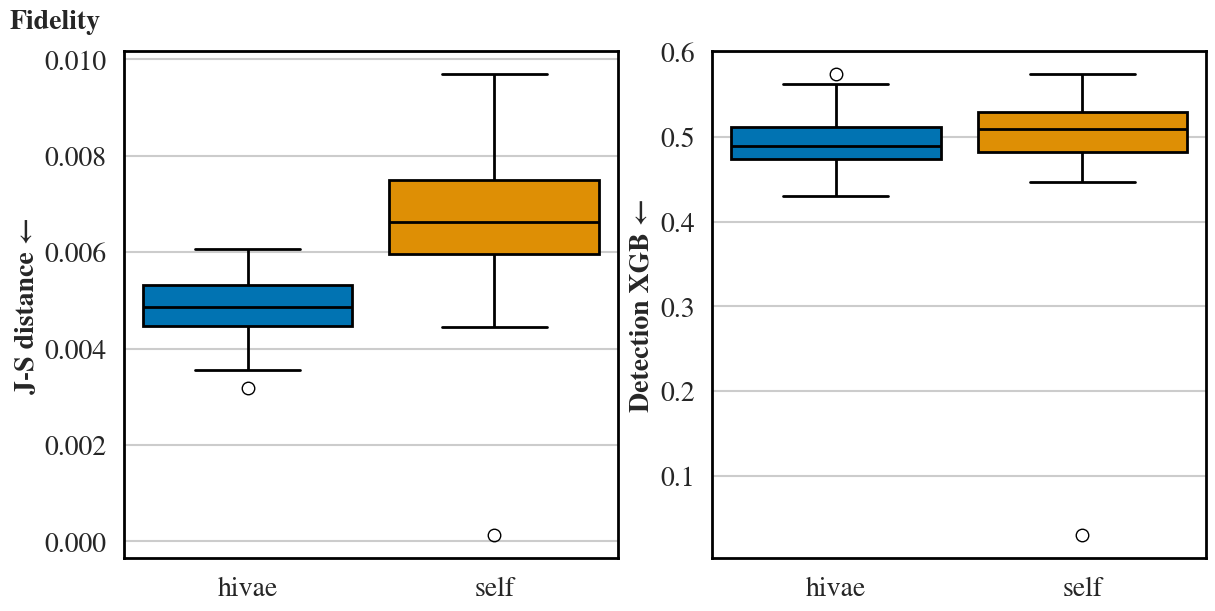

In [22]:
visualize_grouped_perf(score_df_rounded_and_self, {"Fidelity": dict_metrics["Fidelity"]})


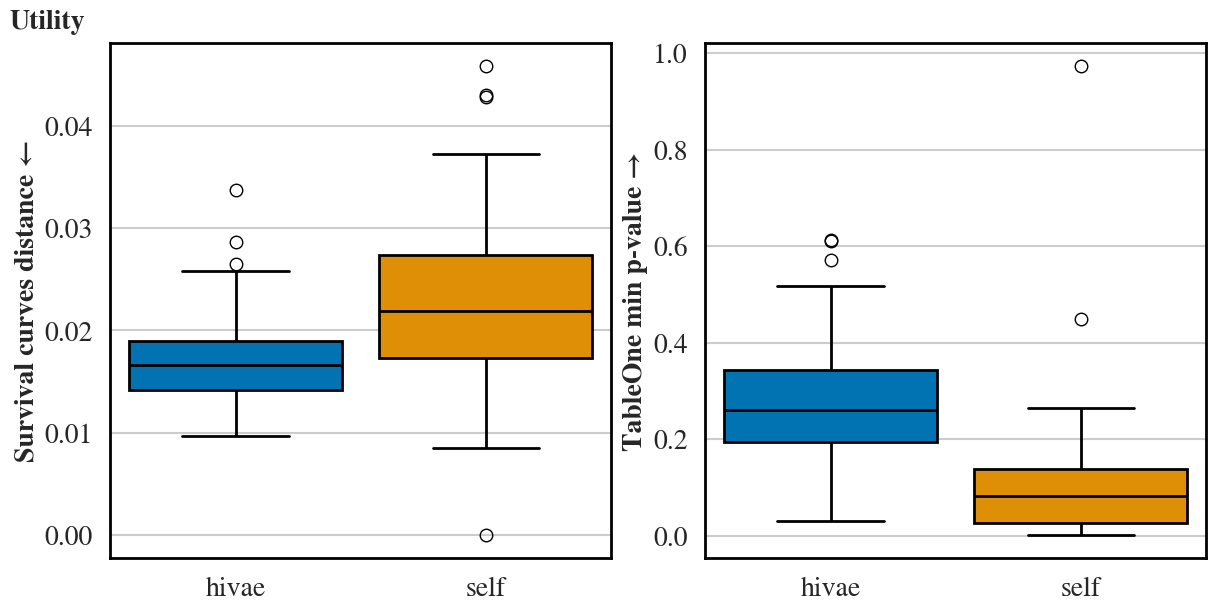

In [23]:
visualize_grouped_perf(score_df_rounded_and_self, {"Utility": dict_metrics["Utility"]})


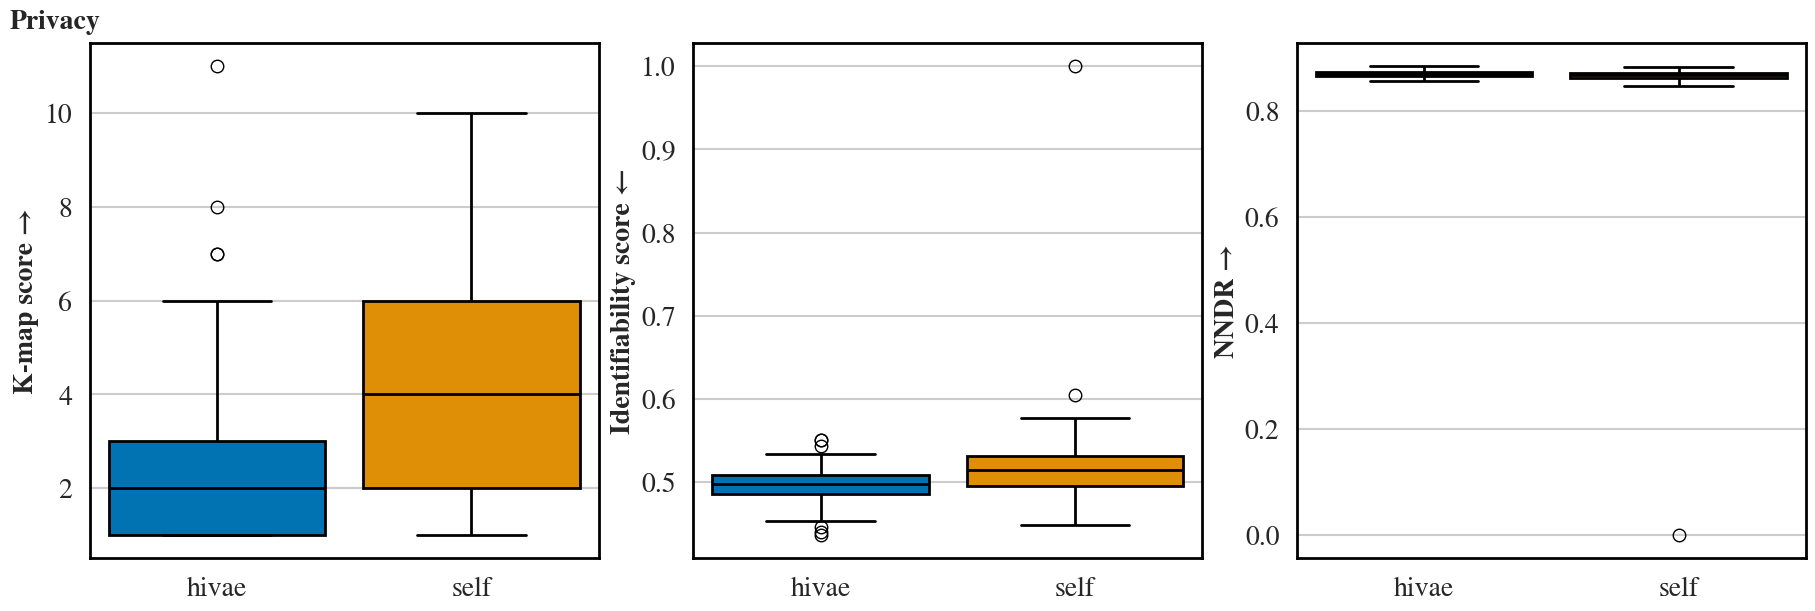

In [24]:
visualize_grouped_perf(score_df_rounded_and_self, {"Privacy": dict_metrics["Privacy"]})
